## Data Loading & Cleaning

The dataset comes from Porto Seguro, a Brazilian auto insurance company, and contains 
595,000 policyholders with 57 anonymized features. The target variable indicates whether 
a policyholder filed a claim (1) or not (0).

Only 3.6% of policyholders filed a claim, creating a significant class imbalance that 
makes raw accuracy a misleading metric. Missing values were encoded as -1 rather than 
NaN — categorical columns were imputed with the mode and continuous columns with the 
median. Two columns (ps_car_03_cat, ps_car_05_cat) were dropped entirely due to over 
65% missingness.

In [22]:
import pandas as pd

df = pd.read_csv('./train.csv')
df = df.drop(columns=['ps_car_03_cat', 'ps_car_05_cat'])

categorical_list = [col for col in df.columns if '_cat' in col]
continuous_list = [col for col in df.columns if '_cat' not in col and '_bin' not in col and 'target' not in col and 'id' not in col]

df['ps_reg_03_missing'] = (df['ps_reg_03'] == -1).astype(int)
df['ps_car_14_missing'] = (df['ps_car_14'] == -1).astype(int)
df['ps_car_07_cat_missing'] = (df['ps_car_07_cat'] == -1).astype(int)
df['ps_ind_05_cat_missing'] = (df['ps_ind_05_cat'] == -1).astype(int)

for category in categorical_list:
    df[category] = df[category].replace(-1, df[category].mode()[0])
for category in continuous_list:
    df[category] = df[category].replace(-1, df[category].median())

df = pd.get_dummies(df, columns=categorical_list)

## Feature Engineering
Three types of aggregation features were created by grouping columns by their prefix (ps_calc, ps_ind, ps_car) and computing the sum, mean, and standard deviation across each group per row. This captures overall policyholder profiles that individual columns cannot. Additionally, binary flags were created for columns with significant missingness, since the absence of information may itself be a risk signal.

In [ ]:
ps_calc_cols = [col for col in df.columns if 'ps_calc' in col]
df['ps_calc_sum'] = df[ps_calc_cols].sum(axis=1)
df['ps_calc_mean'] = df[ps_calc_cols].mean(axis=1)
df['ps_calc_std'] = df[ps_calc_cols].std(axis=1)

ps_ind_cols = [col for col in df.columns if 'ps_ind' in col]
df['ps_ind_sum'] = df[ps_ind_cols].sum(axis=1)
df['ps_ind_mean'] = df[ps_ind_cols].mean(axis=1)
df['ps_ind_std'] = df[ps_ind_cols].std(axis=1)

ps_car_cols = [col for col in df.columns if 'ps_car' in col]
df['ps_car_sum'] = df[ps_car_cols].sum(axis=1)
df['ps_car_mean'] = df[ps_car_cols].mean(axis=1)
df['ps_car_std'] = df[ps_car_cols].std(axis=1)

agg_cols = ['ps_calc_sum', 'ps_calc_mean', 'ps_calc_std',
            'ps_ind_sum', 'ps_ind_mean', 'ps_ind_std',
            'ps_car_sum', 'ps_car_mean', 'ps_car_std']

df[agg_cols] = df[agg_cols].astype(float)
X = df.drop(columns=['target', 'id'])
y = df['target']

## Train/Test Split
The data was split 80/20 into training and test sets using stratified sampling to preserve the 3.6% claim rate in both sets. StandardScaler was applied to normalize features for logistic regression. XGBoost received unscaled data since tree-based models are not sensitive to feature scale.

In [23]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=1, stratify=y)

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Baseline Models
Two baseline models were trained before the primary model. A dummy classifier that always predicts the majority class achieved an AUC of 0.50, equivalent to random guessing. Logistic regression achieved an AUC of 0.630, establishing a meaningful baseline to beat.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

log_model = LogisticRegression()
log_model = log_model.fit(X_train, y_train)
log_probabilities = log_model.predict_proba(X_test)

log_auc = roc_auc_score(y_test, log_probabilities[:,1])

from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_model = dummy_clf.fit(X_train, y_train)
dummy_pro = dummy_clf.predict_proba(X_test)

dummy_aoc = roc_auc_score(y_test, dummy_pro[:,1])

LogisticRegression AUC score is 0.6302457857318958 with the DummyClassifier AUC score being 0.5


## XGBoost
XGBoost was chosen as the primary model due to its strong performance on tabular insurance data and its use in industry actuarial modeling. Hyperparameters were tuned using grid search, with the final model using 500 estimators, learning rate of 0.05, max depth of 7, and subsampling of 0.8 for both rows and columns.

In [25]:
import xgboost as xgb

xgb_clf = xgb.XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=7, subsample=0.8, colsample_bytree=0.8)
xgb_clf.fit(X_train_xgb, y_train)
xgb_prob = xgb_clf.predict_proba(X_test_xgb)

0.6319296081056401


## Results & Feature Importance
The final XGBoost model achieved an AUC of 0.631, corresponding to a Gini coefficient of 0.262. Feature importance analysis revealed that regional variables (ps_reg_03) and car-related features (ps_car_13, ps_car_14) were the strongest predictors, consistent with actuarial intuition that geography and vehicle characteristics are primary drivers of claim risk.

<Figure size 1000x800 with 0 Axes>

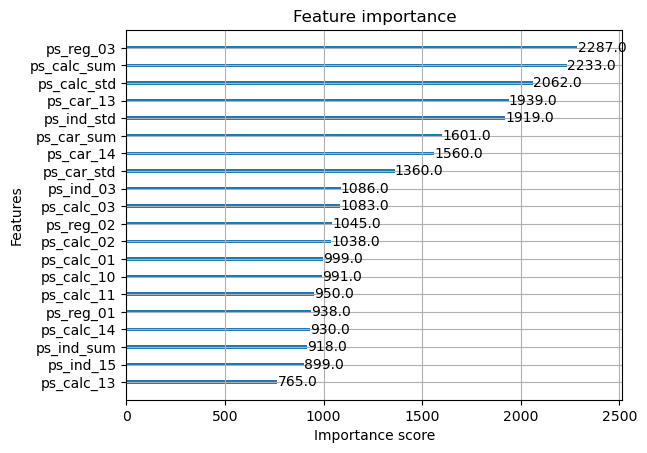

In [26]:
xgb_auc = roc_auc_score(y_test, xgb_prob[:,1])
print(xgb_auc)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_clf, max_num_features=20)
plt.show()